In [1]:
addpath(genpath('../../matlab/utils/tt-toolbox/'));

probname = '2shocks';

tt_times = [];
fg_times = [];

for mesh_scaling = 0:6

tt_file = sprintf('../../matlab/tt_multimat_hydro/matlab/%s_mesh_%d_TT.mat', probname, mesh_scaling);
fg_file = sprintf('../../matlab/tt_multimat_hydro/matlab/%s_mesh_%d_FG.mat', probname, mesh_scaling);

tt = load(tt_file);
fg = load(fg_file);

if exist('tt_times', 'var') 
    tt_times = [tt_times; tt.elapsed_time]; 
end

if exist('fg_times', 'var') 
    fg_times = [fg_times; fg.elapsed_time]; 
end

end

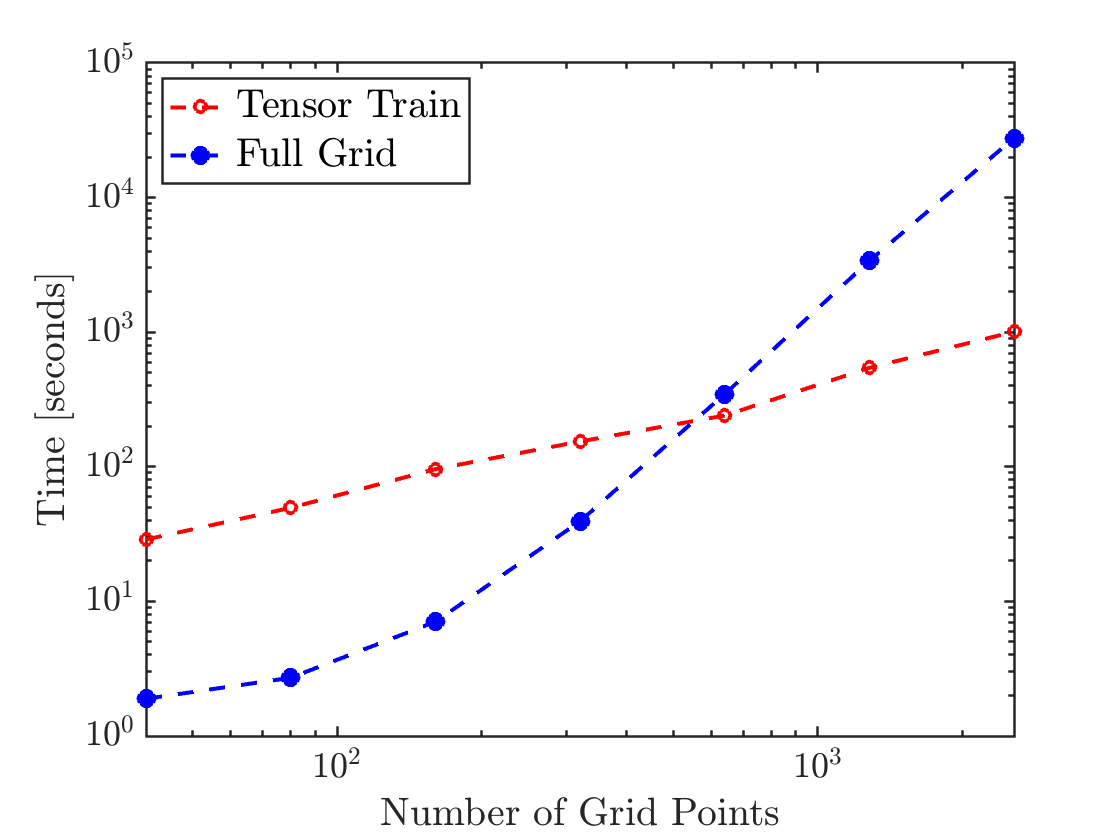

In [3]:
n = [0:6];

x = 2.^n .*40;

plot(x, tt_times, '--o', ...
    'DisplayName','Tensor Train', ...
    'Color','red', ...
    'LineWidth',2);


hold on;

plot(x, fg_times, '--o', ...
    'DisplayName','Full Grid', ...
    'Color','blue', ...
    'LineWidth',2, ...   
    'MarkerSize',8, ...  
    'MarkerFaceColor','blue'); 

xlabel(sprintf('Number of Grid Points'), 'Interpreter','latex', 'FontSize',20);

ylabel(sprintf('Time [seconds]'), 'Interpreter','latex', 'FontSize',20);

legend('FontSize',20,'Interpreter','latex','Location', 'northwest');

set(gca, 'YScale','log', ...
    'FontSize',18, ...
    'LineWidth',1.2, ...
    'TickLabelInterpreter','latex');

set(gca, 'XScale','log')

exportgraphics(gca, './Time_comparison.pdf', 'ContentType','vector', 'BackgroundColor','none');


clf;